In [13]:
# ══════════════════════════════════════════════════════════════════
#  Wheat Leaf Disease Classification — EfficientNetV2-S
#  Single-file notebook | All steps in one place
# ══════════════════════════════════════════════════════════════════

import os, random, json, warnings
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from PIL import Image
from tqdm.notebook import tqdm
from collections import defaultdict
warnings.filterwarnings('ignore')

import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.optim.lr_scheduler import CosineAnnealingLR
from torch.utils.data import DataLoader, Dataset
from torchvision import transforms

import timm
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, classification_report

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device : {device}')
if torch.cuda.is_available():
    print(f'GPU    : {torch.cuda.get_device_name(0)}')
    print(f'VRAM   : {torch.cuda.get_device_properties(0).total_memory/1e9:.1f} GB')

Device : cuda
GPU    : Tesla T4
VRAM   : 15.6 GB


In [ ]:
# ══════════════════════════════════════════════════════════════════
#  STEP 1 — Dataset paths
#  Each path should contain class subfolders, e.g.:
#    Dataset/
#      Brown rust/
#      Healthy/
#      Loose Smut/
#      Septoria/
#      Yellow rust/
# ══════════════════════════════════════════════════════════════════
DATA_DIRS = [
    '/kaggle/input/datasets/jayaprakashpondy/wheat-leaf-disease/Dataset',
]

# ══════════════════════════════════════════════════════════════════
#  STEP 2 — Auto-detect class names from folders
# ══════════════════════════════════════════════════════════════════
CLASSES = sorted(set(
    folder
    for data_dir in DATA_DIRS
    if os.path.exists(data_dir)
    for folder in os.listdir(data_dir)
    if os.path.isdir(os.path.join(data_dir, folder))
))

# ══════════════════════════════════════════════════════════════════
#  STEP 3 — Hyperparameters
# ══════════════════════════════════════════════════════════════════
CFG = {
    'img_size'       : 224,
    'batch_size'     : 16,
    'num_epochs'     : 30,
    'lr'             : 1e-3,
    'fine_tune_lr'   : 1e-5,
    'weight_decay'   : 1e-4,
    'unfreeze_epoch' : 10,    # epoch to unfreeze backbone
    'patience'       : 7,     # early stopping patience
    'seed'           : 42,
    'save_path'      : '/kaggle/working/best_model.pth',
    'num_classes'    : len(CLASSES),
}

def set_seed(seed):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark     = False

set_seed(CFG['seed'])
print(f'Classes     : {CLASSES}')
print(f'Num classes : {CFG["num_classes"]}')
print(f'Datasets    : {len(DATA_DIRS)} source(s)')
print('Config ready ✅')

In [15]:
# ══════════════════════════════════════════════════════════════════
#  Dataset Explorer — scan all folders & report counts
# ══════════════════════════════════════════════════════════════════
print('═'*55)
print('  📁 Dataset Explorer')
print('═'*55)

total_per_class = defaultdict(int)
valid_dirs = []

for data_dir in DATA_DIRS:
    if not os.path.exists(data_dir):
        print(f'\n  ❌ NOT FOUND: {data_dir}')
        continue

    print(f'\n  📂 {data_dir}')
    found_classes = [f for f in sorted(os.listdir(data_dir))
                     if os.path.isdir(os.path.join(data_dir, f))]
    dataset_total = 0

    for cls in CLASSES:
        cls_path = os.path.join(data_dir, cls)
        if os.path.exists(cls_path):
            count = len([f for f in os.listdir(cls_path)
                         if f.lower().endswith(('.jpg','.jpeg','.png','.webp'))])
            total_per_class[cls] += count
            dataset_total        += count
            print(f'     ✅ {cls:<18} {count:>4} images')
        else:
            print(f'     ⚠️  {cls:<18} NOT FOUND')

    ignored = [c for c in found_classes if c not in CLASSES]
    if ignored:
        print(f'     ℹ️  Ignoring: {ignored}')
    print(f'     Subtotal: {dataset_total} images')
    valid_dirs.append(data_dir)

print(f'\n  {"-"*50}')
print('  COMBINED TOTALS:')
grand_total = 0
for cls in CLASSES:
    print(f'    {cls:<20} {total_per_class[cls]:>5} images')
    grand_total += total_per_class[cls]
print(f'    {"TOTAL":<20} {grand_total:>5} images')
print('═'*55)

═══════════════════════════════════════════════════════
  📁 Dataset Explorer
═══════════════════════════════════════════════════════

  📂 /kaggle/input/datasets/jayaprakashpondy/wheat-leaf-disease/Dataset
     ✅ Brown rust         1256 images
     ✅ Healthy            1591 images
     ✅ Loose Smut          930 images
     ✅ Septoria            349 images
     ✅ Yellow rust        1395 images
     Subtotal: 5521 images

  --------------------------------------------------
  COMBINED TOTALS:
    Brown rust            1256 images
    Healthy               1591 images
    Loose Smut             930 images
    Septoria               349 images
    Yellow rust           1395 images
    TOTAL                 5521 images
═══════════════════════════════════════════════════════


In [16]:
# ══════════════════════════════════════════════════════════════════
#  Build image paths + labels, then split 70 / 15 / 15
# ══════════════════════════════════════════════════════════════════
IMG_EXTENSIONS = ('.jpg', '.jpeg', '.png', '.webp')
class2idx = {cls: i for i, cls in enumerate(CLASSES)}

all_paths, all_labels = [], []
for data_dir in valid_dirs:
    for cls in CLASSES:
        cls_path = os.path.join(data_dir, cls)
        if not os.path.exists(cls_path):
            continue
        for fname in os.listdir(cls_path):
            if fname.lower().endswith(IMG_EXTENSIONS):
                all_paths.append(os.path.join(cls_path, fname))
                all_labels.append(class2idx[cls])

all_paths  = np.array(all_paths)
all_labels = np.array(all_labels)

# Stratified 70 / 15 / 15 split
train_idx, temp_idx = train_test_split(
    np.arange(len(all_labels)), test_size=0.30,
    stratify=all_labels, random_state=CFG['seed'])
val_idx, test_idx = train_test_split(
    temp_idx, test_size=0.50,
    stratify=all_labels[temp_idx], random_state=CFG['seed'])

print(f'Train : {len(train_idx):>5} images')
print(f'Val   : {len(val_idx):>5} images')
print(f'Test  : {len(test_idx):>5} images')
print(f'Total : {len(all_labels):>5} images')

Train :  3864 images
Val   :   828 images
Test  :   829 images
Total :  5521 images


In [17]:
# ══════════════════════════════════════════════════════════════════
#  Transforms & Dataset
# ══════════════════════════════════════════════════════════════════
MEAN = [0.485, 0.456, 0.406]
STD  = [0.229, 0.224, 0.225]

train_tf = transforms.Compose([
    transforms.RandomResizedCrop(CFG['img_size'], scale=(0.7, 1.0)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomVerticalFlip(),
    transforms.ColorJitter(brightness=0.3, contrast=0.3, saturation=0.3, hue=0.1),
    transforms.RandomRotation(20),
    transforms.RandomGrayscale(p=0.05),
    transforms.ToTensor(),
    transforms.Normalize(MEAN, STD),
])

val_tf = transforms.Compose([
    transforms.Resize(256),
    transforms.CenterCrop(CFG['img_size']),
    transforms.ToTensor(),
    transforms.Normalize(MEAN, STD),
])

class WheatDataset(Dataset):
    def __init__(self, paths, labels, transform=None):
        self.paths     = paths
        self.labels    = labels
        self.transform = transform

    def __len__(self):
        return len(self.paths)

    def __getitem__(self, idx):
        img = Image.open(self.paths[idx]).convert('RGB')
        if self.transform:
            img = self.transform(img)
        return img, self.labels[idx]

train_ds = WheatDataset(all_paths[train_idx], all_labels[train_idx], train_tf)
val_ds   = WheatDataset(all_paths[val_idx],   all_labels[val_idx],   val_tf)
test_ds  = WheatDataset(all_paths[test_idx],  all_labels[test_idx],  val_tf)

train_loader = DataLoader(train_ds, batch_size=CFG['batch_size'], shuffle=True,
                          num_workers=2, pin_memory=True)
val_loader   = DataLoader(val_ds,   batch_size=CFG['batch_size'], shuffle=False,
                          num_workers=2, pin_memory=True)
test_loader  = DataLoader(test_ds,  batch_size=CFG['batch_size'], shuffle=False,
                          num_workers=2, pin_memory=True)

print(f'Loaders ready — train batches: {len(train_loader)}, val: {len(val_loader)}, test: {len(test_loader)}')

Loaders ready — train batches: 242, val: 52, test: 52


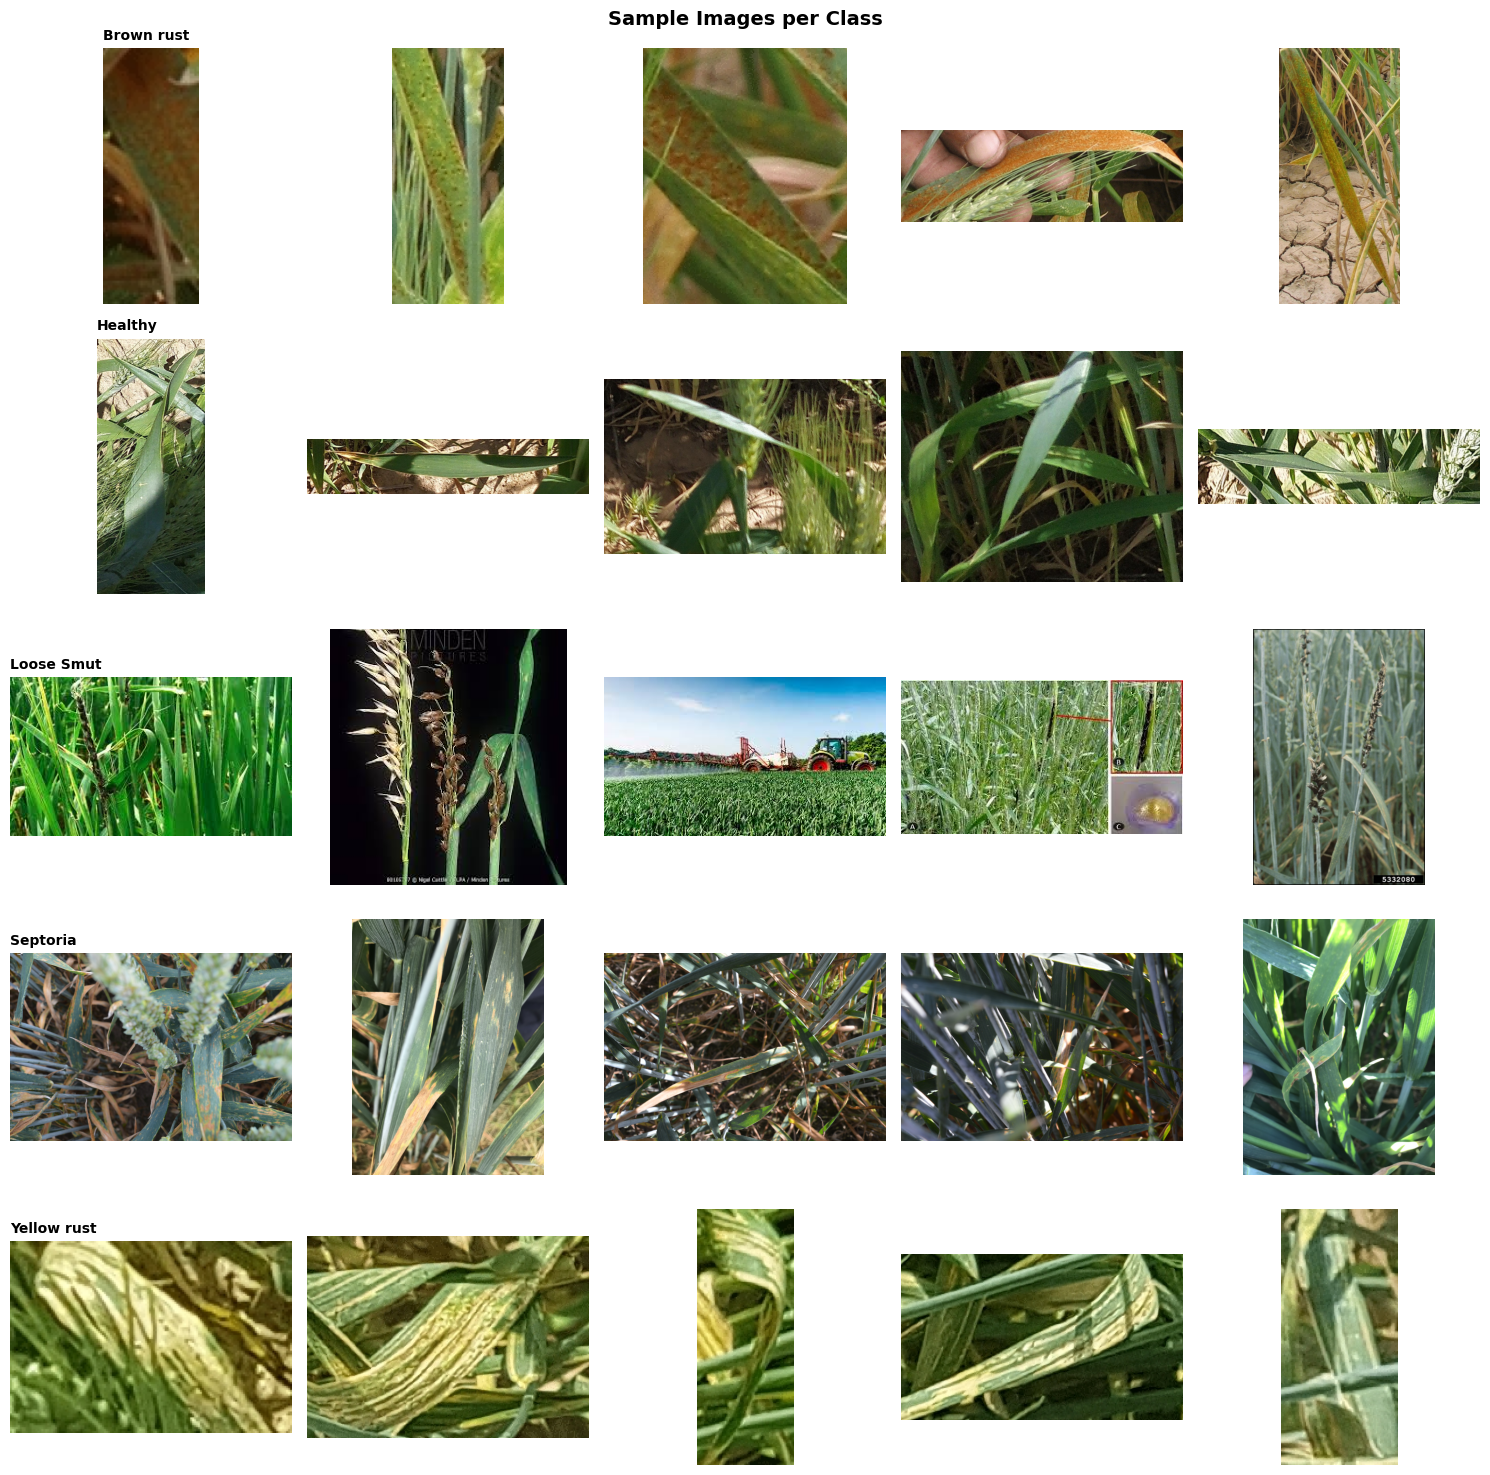

Saved sample_images.png ✅


In [18]:
# ══════════════════════════════════════════════════════════════════
#  Sample Image Grid
# ══════════════════════════════════════════════════════════════════
fig, axes = plt.subplots(CFG['num_classes'], 5, figsize=(15, 3*CFG['num_classes']))
fig.suptitle('Sample Images per Class', fontsize=14, fontweight='bold')

for row, cls in enumerate(CLASSES):
    cls_idx  = class2idx[cls]
    cls_imgs = all_paths[all_labels == cls_idx]
    samples  = np.random.choice(cls_imgs, min(5, len(cls_imgs)), replace=False)
    for col, img_path in enumerate(samples):
        ax = axes[row, col] if CFG['num_classes'] > 1 else axes[col]
        ax.imshow(Image.open(img_path).convert('RGB'))
        ax.axis('off')
        if col == 0:
            ax.set_title(cls, fontsize=10, fontweight='bold', loc='left')

plt.tight_layout()
plt.savefig('/kaggle/working/sample_images.png', dpi=100, bbox_inches='tight')
plt.show()
print('Saved sample_images.png ✅')

In [19]:

#  Model — EfficientNetV2-S with frozen backbone
#  Backbone unfreezes at epoch `unfreeze_epoch` for fine-tuning
# ══════════════════════════════════════════════════════════════════
class EfficientNetV2S(nn.Module):
    def __init__(self, num_classes, dropout=0.3):
        super().__init__()
        self.backbone = timm.create_model(
            'tf_efficientnetv2_s',
            pretrained=True,
            num_classes=0,       # remove classifier head
            global_pool='avg'
        )
        feat_dim = self.backbone.num_features
        self.head = nn.Sequential(
            nn.Dropout(dropout),
            nn.Linear(feat_dim, num_classes)
        )
        # Freeze backbone initially
        for p in self.backbone.parameters():
            p.requires_grad = False

    def unfreeze_backbone(self):
        for p in self.backbone.parameters():
            p.requires_grad = True

    def forward(self, x):
        return self.head(self.backbone(x))

model = EfficientNetV2S(CFG['num_classes']).to(device)

total_params     = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f'Model      : EfficientNetV2-S')
print(f'Total      : {total_params:,} parameters')
print(f'Trainable  : {trainable_params:,} (head only — backbone frozen)')
print(f'Backbone unfreezes at epoch {CFG["unfreeze_epoch"]}')

Model      : EfficientNetV2-S
Total      : 20,183,893 parameters
Trainable  : 6,405 (head only — backbone frozen)
Backbone unfreezes at epoch 10


In [20]:
# ══════════════════════════════════════════════════════════════════
#  Class-weighted loss + optimizer + scheduler
# ══════════════════════════════════════════════════════════════════
# Compute class weights from training set
train_labels = all_labels[train_idx]
counts       = np.bincount(train_labels, minlength=CFG['num_classes']).astype(float)
weights      = 1.0 / counts
weights      = weights / weights.sum() * CFG['num_classes']
class_weights = torch.tensor(weights, dtype=torch.float32).to(device)

criterion = nn.CrossEntropyLoss(weight=class_weights)

optimizer = optim.AdamW(
    filter(lambda p: p.requires_grad, model.parameters()),
    lr=CFG['lr'], weight_decay=CFG['weight_decay']
)
scheduler = CosineAnnealingLR(optimizer, T_max=CFG['num_epochs'])

print('Class weights:', {cls: f'{w:.3f}' for cls, w in zip(CLASSES, weights)})
print('Loss / Optimizer / Scheduler ready ✅')

Class weights: {'Brown rust': '0.654', 'Healthy': '0.516', 'Loose Smut': '0.883', 'Septoria': '2.357', 'Yellow rust': '0.589'}
Loss / Optimizer / Scheduler ready ✅


In [ ]:
# ══════════════════════════════════════════════════════════════════
#  Training Loop  (frozen backbone → unfreeze at unfreeze_epoch)
# ══════════════════════════════════════════════════════════════════
history = {'train_loss':[], 'train_acc':[], 'val_loss':[], 'val_acc':[]}
best_val_loss = float('inf')
best_val_acc  = 0.0
patience_ctr  = 0
unfrozen      = False

def run_epoch(loader, training):
    model.train() if training else model.eval()
    total_loss, correct, total = 0.0, 0, 0
    ctx = torch.enable_grad() if training else torch.no_grad()
    with ctx:
        for imgs, labels in loader:
            imgs, labels = imgs.to(device), labels.to(device)
            if training:
                optimizer.zero_grad()
            out  = model(imgs)
            loss = criterion(out, labels)
            if training:
                loss.backward()
                optimizer.step()
            total_loss += loss.item() * imgs.size(0)
            correct    += (out.argmax(1) == labels).sum().item()
            total      += imgs.size(0)
    return total_loss / total, correct / total

print(f'Starting training for up to {CFG["num_epochs"]} epochs...')
print(f'Backbone unfreezes at epoch {CFG["unfreeze_epoch"]}\n')

for epoch in range(1, CFG['num_epochs'] + 1):

    # ── Unfreeze backbone at scheduled epoch ──
    if epoch == CFG['unfreeze_epoch'] and not unfrozen:
        model.unfreeze_backbone()
        # Reset optimizer with lower lr for backbone
        optimizer = optim.AdamW(model.parameters(),
                                lr=CFG['fine_tune_lr'],
                                weight_decay=CFG['weight_decay'])
        scheduler = CosineAnnealingLR(optimizer,
                                      T_max=CFG['num_epochs'] - epoch + 1)
        unfrozen = True
        print(f'  🔓 Epoch {epoch}: backbone unfrozen — lr → {CFG["fine_tune_lr"]}')

    tr_loss, tr_acc = run_epoch(train_loader, training=True)
    vl_loss, vl_acc = run_epoch(val_loader,   training=False)
    scheduler.step()

    history['train_loss'].append(tr_loss)
    history['train_acc'].append(tr_acc)
    history['val_loss'].append(vl_loss)
    history['val_acc'].append(vl_acc)

    # ── Checkpoint & early stopping ──
    improved = vl_loss < best_val_loss
    if improved:
        best_val_loss = vl_loss
        best_val_acc  = vl_acc
        patience_ctr  = 0
        torch.save({'epoch': epoch, 'model_state': model.state_dict(),
                    'val_loss': vl_loss, 'val_acc': vl_acc,
                    'classes': CLASSES},
                   CFG['save_path'])
        tag = '✅ saved'
    else:
        patience_ctr += 1
        tag = f'(patience {patience_ctr}/{CFG["patience"]})'

    print(f'Epoch {epoch:>3}/{CFG["num_epochs"]} | '
          f'Train loss {tr_loss:.4f} acc {tr_acc:.3f} | '
          f'Val loss {vl_loss:.4f} acc {vl_acc:.3f} | {tag}')

    if patience_ctr >= CFG['patience']:
        print(f'\n  Early stopping at epoch {epoch}')
        break

print(f'\nBest val loss : {best_val_loss:.4f}')
print(f'Best val acc  : {best_val_acc:.3f}')

Starting training for up to 30 epochs...
Backbone unfreezes at epoch 10

Epoch   1/30 | Train loss 0.6834 acc 0.769 | Val loss 0.4410 acc 0.862 | ✅ saved
Epoch   2/30 | Train loss 0.4716 acc 0.843 | Val loss 0.3470 acc 0.885 | ✅ saved
Epoch   3/30 | Train loss 0.4652 acc 0.831 | Val loss 0.3495 acc 0.882 | (patience 1/7)
Epoch   4/30 | Train loss 0.4203 acc 0.848 | Val loss 0.3476 acc 0.896 | (patience 2/7)
Epoch   5/30 | Train loss 0.4208 acc 0.855 | Val loss 0.3167 acc 0.886 | ✅ saved
Epoch   6/30 | Train loss 0.4289 acc 0.849 | Val loss 0.3059 acc 0.890 | ✅ saved
Epoch   7/30 | Train loss 0.4306 acc 0.848 | Val loss 0.2950 acc 0.901 | ✅ saved
Epoch   8/30 | Train loss 0.4439 acc 0.856 | Val loss 0.2904 acc 0.901 | ✅ saved
Epoch   9/30 | Train loss 0.4052 acc 0.856 | Val loss 0.3022 acc 0.893 | (patience 1/7)
  🔓 Epoch 10: backbone unfrozen — lr → 1e-05
Epoch  10/30 | Train loss 0.3655 acc 0.874 | Val loss 0.2532 acc 0.900 | ✅ saved
Epoch  11/30 | Train loss 0.3337 acc 0.880 | Val lo

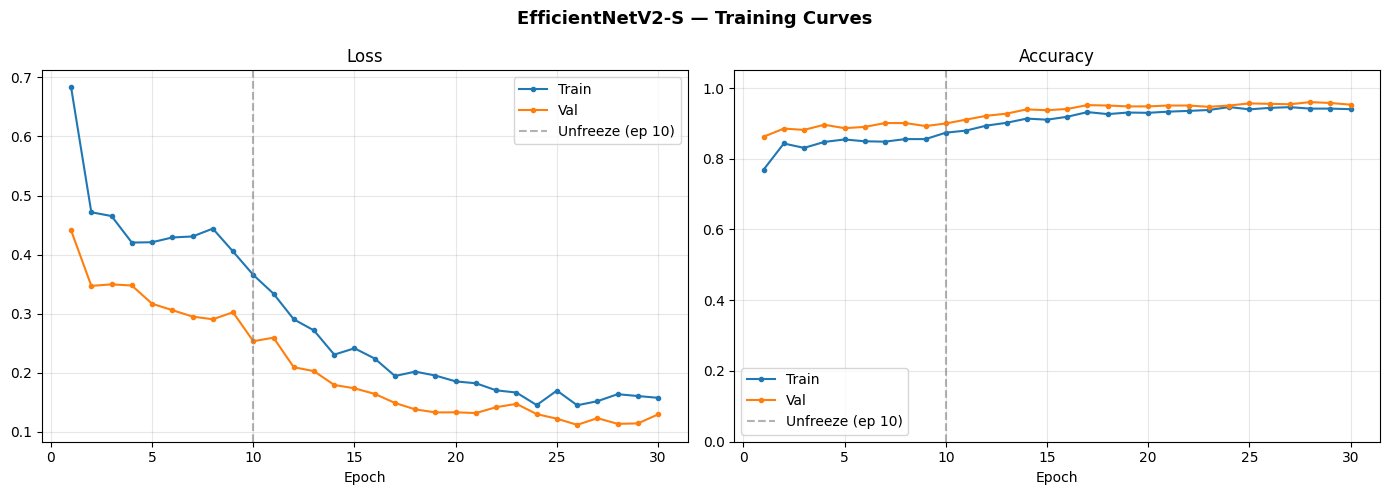

Saved training_curves.png ✅


In [29]:
# ══════════════════════════════════════════════════════════════════
#  Training Curves
# ══════════════════════════════════════════════════════════════════
epochs = range(1, len(history['train_loss']) + 1)
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('EfficientNetV2-S — Training Curves', fontsize=13, fontweight='bold')

axes[0].plot(epochs, history['train_loss'], label='Train', marker='o', ms=3)
axes[0].plot(epochs, history['val_loss'],   label='Val',   marker='o', ms=3)
axes[0].axvline(x=CFG['unfreeze_epoch'], color='gray', ls='--', alpha=0.6, label=f'Unfreeze (ep {CFG["unfreeze_epoch"]})')
axes[0].set_title('Loss'); axes[0].set_xlabel('Epoch'); axes[0].legend()
axes[0].grid(alpha=0.3)

axes[1].plot(epochs, history['train_acc'], label='Train', marker='o', ms=3)
axes[1].plot(epochs, history['val_acc'],   label='Val',   marker='o', ms=3)
axes[1].axvline(x=CFG['unfreeze_epoch'], color='gray', ls='--', alpha=0.6, label=f'Unfreeze (ep {CFG["unfreeze_epoch"]})')
axes[1].set_title('Accuracy'); axes[1].set_xlabel('Epoch'); axes[1].legend()
axes[1].set_ylim(0, 1.05); axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig('/kaggle/working/training_curves.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved training_curves.png ✅')

In [30]:
# ══════════════════════════════════════════════════════════════════
#  Test Evaluation — load best checkpoint
# ══════════════════════════════════════════════════════════════════
checkpoint = torch.load(CFG['save_path'], map_location=device)
model.load_state_dict(checkpoint['model_state'])
print(f'Loaded best checkpoint from epoch {checkpoint["epoch"]} '
      f'(val_loss={checkpoint["val_loss"]:.4f}, val_acc={checkpoint["val_acc"]:.3f})')

model.eval()
all_preds, all_true = [], []

with torch.no_grad():
    for imgs, labels in tqdm(test_loader, desc='Testing'):
        imgs = imgs.to(device)
        preds = model(imgs).argmax(1).cpu().numpy()
        all_preds.extend(preds)
        all_true.extend(labels.numpy())

all_preds = np.array(all_preds)
all_true  = np.array(all_true)
test_acc  = (all_preds == all_true).mean()

print(f'\nTest Accuracy : {test_acc:.4f} ({test_acc*100:.2f}%)')
print('\nClassification Report:')
print(classification_report(all_true, all_preds, target_names=CLASSES))

Loaded best checkpoint from epoch 26 (val_loss=0.1116, val_acc=0.955)


Testing:   0%|          | 0/52 [00:00<?, ?it/s]


Test Accuracy : 0.9530 (95.30%)

Classification Report:
              precision    recall  f1-score   support

  Brown rust       0.92      0.98      0.95       189
     Healthy       0.99      0.96      0.97       239
  Loose Smut       1.00      0.96      0.98       139
    Septoria       0.81      0.96      0.88        52
 Yellow rust       0.96      0.91      0.94       210

    accuracy                           0.95       829
   macro avg       0.93      0.96      0.94       829
weighted avg       0.96      0.95      0.95       829



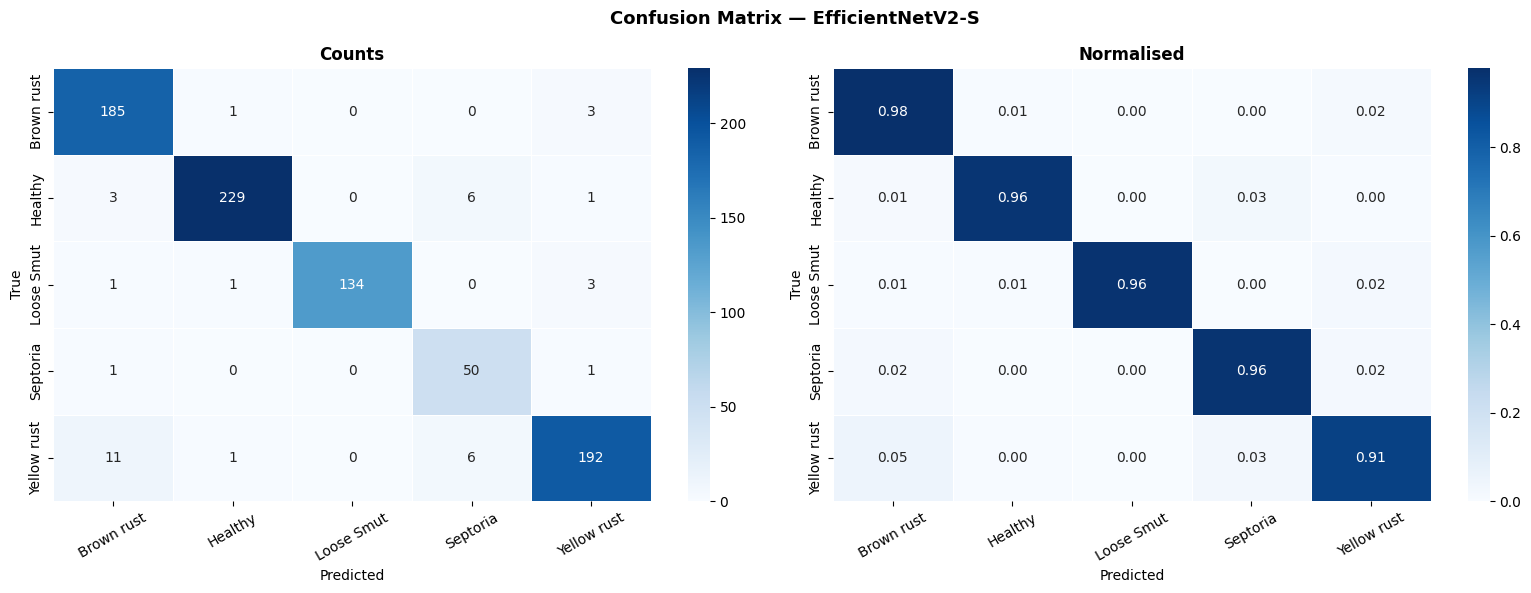

Saved confusion_matrix.png ✅


In [31]:
# ══════════════════════════════════════════════════════════════════
#  Confusion Matrix
# ══════════════════════════════════════════════════════════════════
cm = confusion_matrix(all_true, all_preds)
cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('Confusion Matrix — EfficientNetV2-S', fontsize=13, fontweight='bold')

for ax, data, title, fmt in [
    (axes[0], cm,      'Counts',       'd'),
    (axes[1], cm_norm, 'Normalised',   '.2f'),
]:
    sns.heatmap(data, annot=True, fmt=fmt, cmap='Blues',
                xticklabels=CLASSES, yticklabels=CLASSES, ax=ax,
                linewidths=0.5, cbar=True)
    ax.set_title(title, fontweight='bold')
    ax.set_xlabel('Predicted'); ax.set_ylabel('True')
    ax.tick_params(axis='x', rotation=30)

plt.tight_layout()
plt.savefig('/kaggle/working/confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved confusion_matrix.png ✅')

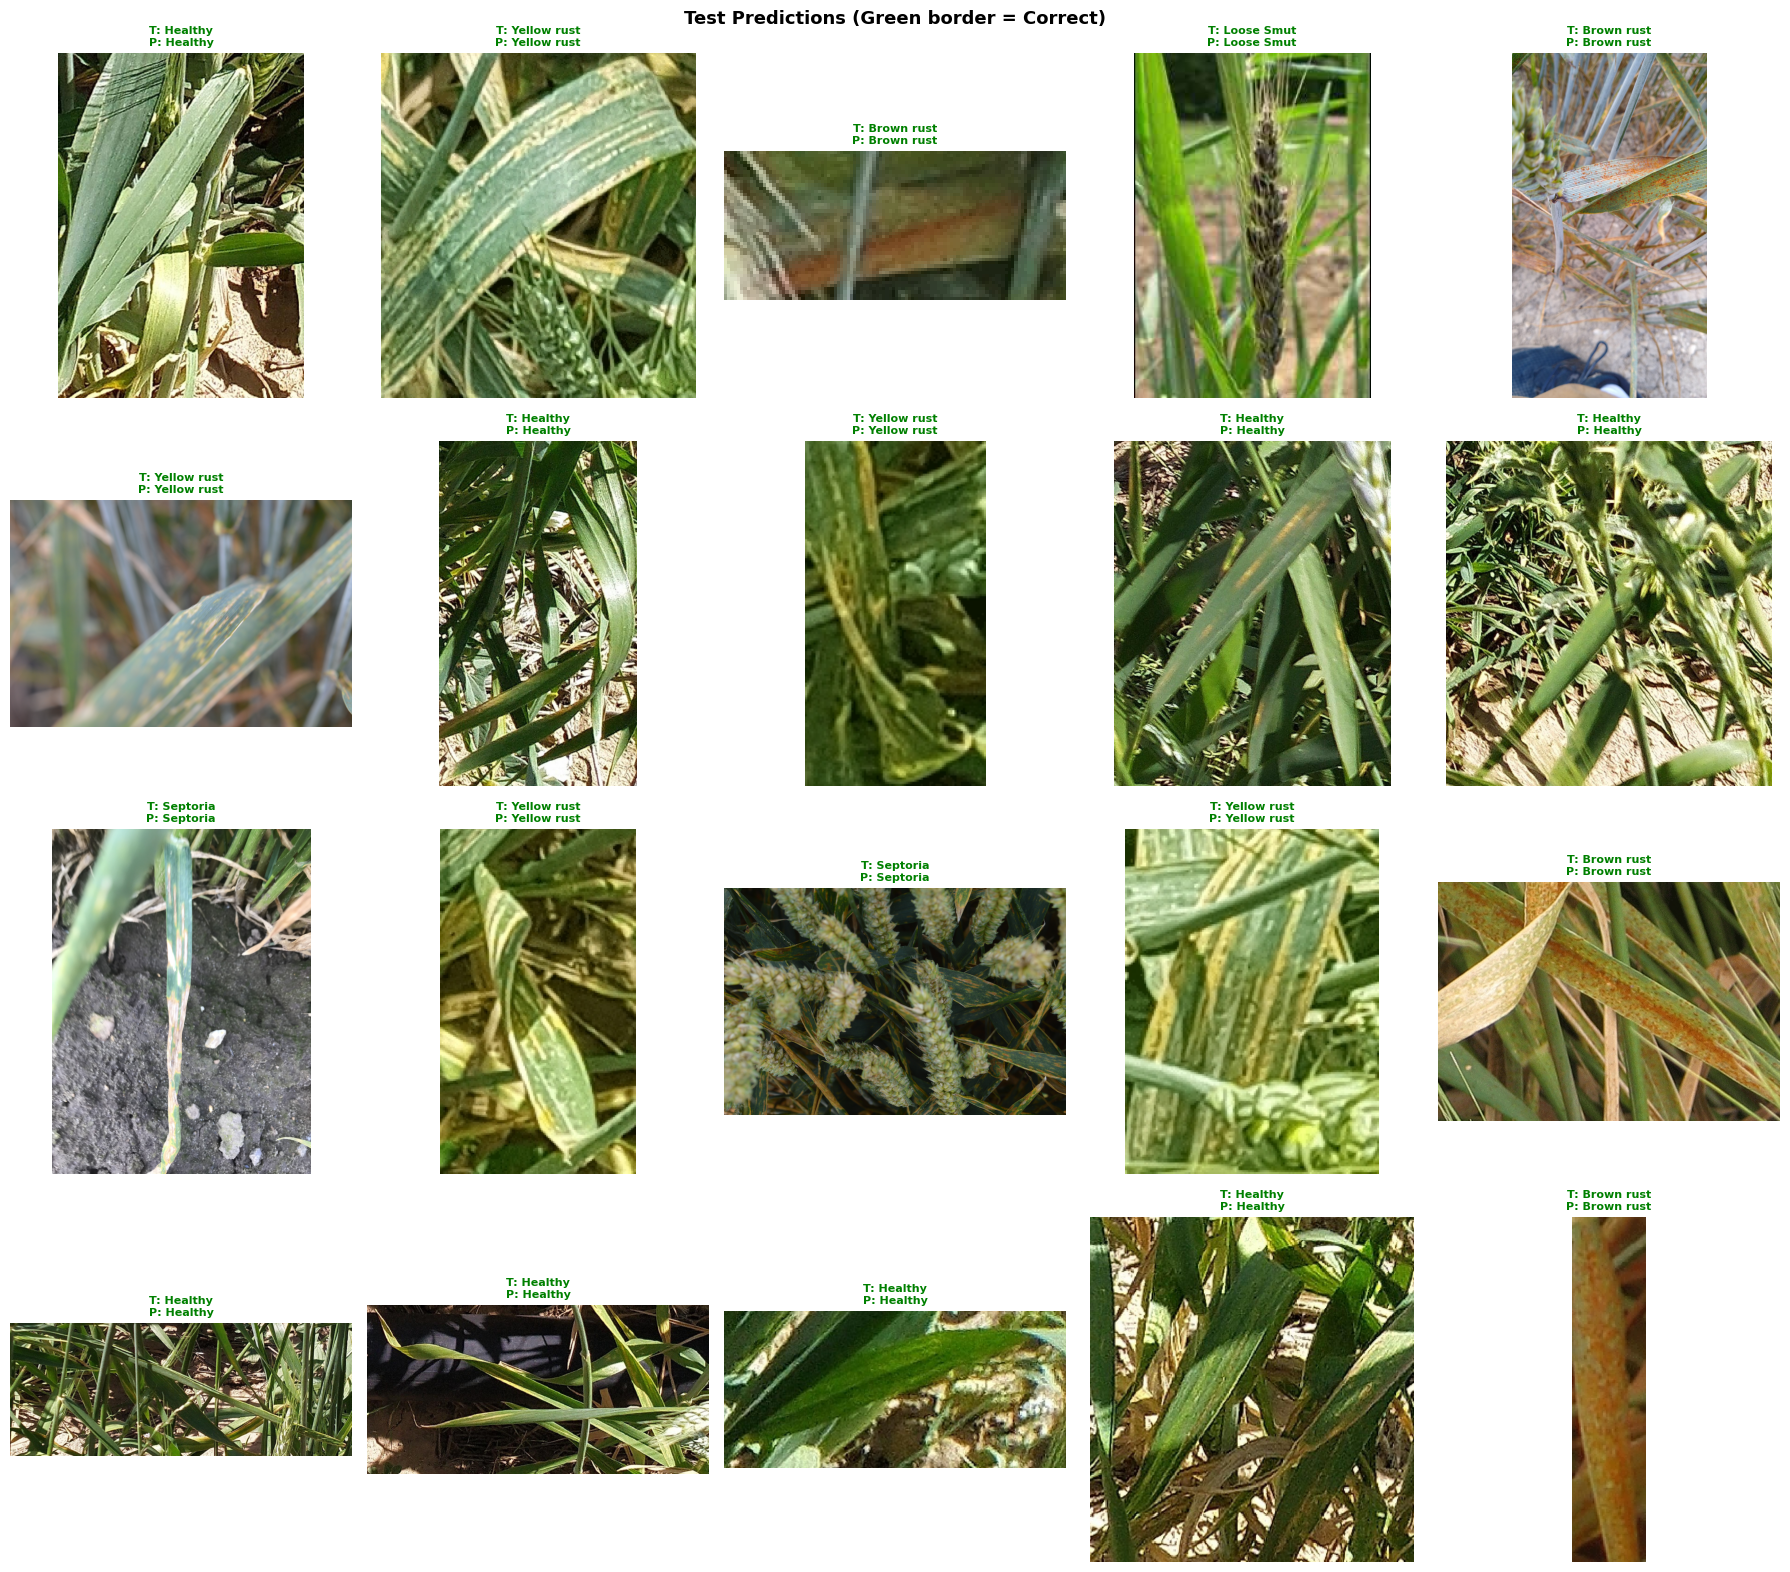

Saved predictions.png ✅


In [32]:
# ══════════════════════════════════════════════════════════════════
#  Prediction Grid — sample test images with results
# ══════════════════════════════════════════════════════════════════
COLORS = plt.cm.Set2.colors
cls_colors = {cls: COLORS[i % len(COLORS)] for i, cls in enumerate(CLASSES)}

n_show = min(20, len(test_idx))
sample_idx = np.random.choice(len(test_idx), n_show, replace=False)

nrows = (n_show + 4) // 5
fig, axes = plt.subplots(nrows, 5, figsize=(18, 4*nrows))
fig.suptitle('Test Predictions (Green border = Correct)', fontsize=13, fontweight='bold')
axes = axes.flatten()

for i, si in enumerate(sample_idx):
    img_path = all_paths[test_idx[si]]
    true_lbl = all_labels[test_idx[si]]
    pred_lbl = all_preds[si]

    img = Image.open(img_path).convert('RGB')
    axes[i].imshow(img)
    axes[i].axis('off')

    correct = true_lbl == pred_lbl
    border_color = '#2ecc71' if correct else '#e74c3c'
    for spine in axes[i].spines.values():
        spine.set_edgecolor(border_color)
        spine.set_linewidth(4)
        spine.set_visible(True)

    axes[i].set_title(
        f'T: {CLASSES[true_lbl]}\nP: {CLASSES[pred_lbl]}',
        fontsize=8,
        color='green' if correct else 'red',
        fontweight='bold'
    )

for j in range(n_show, len(axes)):
    axes[j].axis('off')

plt.tight_layout()
plt.savefig('/kaggle/working/predictions.png', dpi=120, bbox_inches='tight')
plt.show()
print('Saved predictions.png ✅')

In [1]:
# ══════════════════════════════════════════════════════════════════
#  Save training history & dataset info
# ══════════════════════════════════════════════════════════════════
with open('/kaggle/working/training_history.json', 'w') as f:
    json.dump(history, f, indent=2)

dataset_info = {
    'data_dirs'   : valid_dirs,
    'classes'     : CLASSES,
    'num_classes' : CFG['num_classes'],
    'train_size'  : len(train_idx),
    'val_size'    : len(val_idx),
    'test_size'   : len(test_idx),
    'test_acc'    : float(test_acc),
    'model'       : 'EfficientNetV2-S (tf_efficientnetv2_s)',
}
with open('/kaggle/working/dataset_info.json', 'w') as f:
    json.dump(dataset_info, f, indent=2)

print('All outputs saved to /kaggle/working/:')
for fname in sorted(os.listdir('/kaggle/working/')):
    fp = os.path.join('/kaggle/working/', fname)
    if os.path.isfile(fp):
        print(f'  {fname:<40} {os.path.getsize(fp)/1024:.1f} KB')

NameError: name 'json' is not defined

In [ ]:
# ══════════════════════════════════════════════════════════════════
#  INFERENCE — Run on your own image
#  1. Upload an image via Add Data → Upload
#  2. Run the cell below to find its path
#  3. Set IMAGE_PATH and run the prediction cell
# ══════════════════════════════════════════════════════════════════
print('📁 Your uploaded images:')
found = False
for root, dirs, files in os.walk('/kaggle/input/'):
    for f in files:
        if f.lower().endswith(('.jpg','.jpeg','.png','.webp')):
            print(f'  {os.path.join(root, f)}')
            found = True
if not found:
    print('  No images found yet. Upload one via Add Data → Upload.')

In [2]:
# ══════════════════════════════════════════════════════════════════
#  ✏️  Point to a FOLDER of images — all will be predicted
# ══════════════════════════════════════════════════════════════════
FOLDER_PATH = '/kaggle/input/datasets/kushagra3204/wheat-plant-diseases'
# ══════════════════════════════════════════════════════════════════

CLASS_COLORS = [
    '#2ecc71','#f39c12','#e74c3c','#3498db','#9b59b6',
    '#1abc9c','#e67e22','#c0392b','#2980b9','#8e44ad',
]
CLS_COLOR = {cls: CLASS_COLORS[i % len(CLASS_COLORS)] for i, cls in enumerate(CLASSES)}
CLASS_EMOJI = ['🟢','🟡','🔴','🔵','🟣']
CLS_EMOJI   = {cls: CLASS_EMOJI[i % len(CLASS_EMOJI)] for i, cls in enumerate(CLASSES)}

# ── Collect all images in the folder (recursively) ───────────────
IMG_EXTS = ('.jpg', '.jpeg', '.png', '.webp', '.bmp')
img_paths = []
for root, _, files in os.walk(FOLDER_PATH):
    for f in sorted(files):
        if f.lower().endswith(IMG_EXTS):
            img_paths.append(os.path.join(root, f))

assert len(img_paths) > 0, f'❌ No images found in: {FOLDER_PATH}'
print(f'Found {len(img_paths)} image(s) in {FOLDER_PATH}\n')

# ── Transforms ───────────────────────────────────────────────────
inf_tf = transforms.Compose([
    transforms.Resize((CFG['img_size'], CFG['img_size'])),
    transforms.ToTensor(),
    transforms.Normalize(MEAN, STD),
])
tta_tf = transforms.Compose([
    transforms.Resize(404),
    transforms.RandomCrop(CFG['img_size']),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
    transforms.Normalize(MEAN, STD),
])

# ── Predict each image ───────────────────────────────────────────
model.eval()
results = []

for img_path in tqdm(img_paths, desc='Predicting'):
    try:
        img = Image.open(img_path).convert('RGB')
    except Exception as e:
        print(f'  ⚠️  Skipping {os.path.basename(img_path)}: {e}')
        continue

    # Standard pass
    t = inf_tf(img).unsqueeze(0).to(device)
    with torch.no_grad():
        probs = F.softmax(model(t), dim=1).squeeze().cpu().numpy()

    # TTA — 5 augmented passes
    tta_p = probs.copy()
    for _ in range(5):
        ta = tta_tf(img).unsqueeze(0).to(device)
        with torch.no_grad():
            tta_p += F.softmax(model(ta), dim=1).squeeze().cpu().numpy()
    tta_p /= 6

    results.append({
        'path'      : img_path,
        'img'       : img,
        'probs'     : probs,
        'tta_probs' : tta_p,
        'pred'      : CLASSES[probs.argmax()],
        'tta_pred'  : CLASSES[tta_p.argmax()],
        'conf'      : float(probs.max()),
        'tta_conf'  : float(tta_p.max()),
    })

print(f'\nDone — {len(results)} image(s) predicted.')

# ── Summary table ─────────────────────────────────────────────────
print()
print('═'*72)
print(f'  {"File":<30} {"TTA Prediction":<20} {"Confidence"}')
print('─'*72)
for r in results:
    fname = os.path.basename(r['path'])[:29]
    emoji = CLS_EMOJI.get(r['tta_pred'], '?')
    print(f'  {fname:<30} {emoji} {r["tta_pred"]:<18} {r["tta_conf"]:.2%}')
print('═'*72)

# ── Class tally ──────────────────────────────────────────────────
from collections import Counter
tally = Counter(r['tta_pred'] for r in results)
print('\nPrediction breakdown:')
for cls in CLASSES:
    bar = '█' * tally.get(cls, 0)
    print(f'  {CLS_EMOJI.get(cls,"")} {cls:<20} {tally.get(cls,0):>3}  {bar}')

# ── Visual grid (up to 20 images) ────────────────────────────────
N     = min(20, len(results))
cols  = 5
rows  = (N + cols - 1) // cols

fig, axes = plt.subplots(rows, cols, figsize=(cols*3.5, rows*3.8), facecolor='#f0f0f0')
fig.suptitle(f'Folder Predictions — EfficientNetV2-S  ({N} of {len(results)} shown)',
             fontsize=13, fontweight='bold', y=1.01)
axes = np.array(axes).flatten()

for i, r in enumerate(results[:N]):
    ax    = axes[i]
    emoji = CLS_EMOJI.get(r['tta_pred'], '?')
    color = CLS_COLOR.get(r['tta_pred'], '#555')

    ax.imshow(r['img'])
    ax.axis('off')
    ax.set_title(
        f"{emoji} {r['tta_pred']}\n{r['tta_conf']:.1%}",
        fontsize=8.5, fontweight='bold', color=color
    )
    # Coloured border
    for spine in ax.spines.values():
        spine.set_edgecolor(color)
        spine.set_linewidth(4)
        spine.set_visible(True)

for j in range(N, len(axes)):
    axes[j].axis('off')

plt.tight_layout()
plt.savefig('/kaggle/working/folder_predictions.png', dpi=120, bbox_inches='tight')
plt.show()
print('\nSaved → /kaggle/working/folder_predictions.png ✅')

# ── Per-image confidence bar charts (first 5 only) ───────────────
M = min(5, len(results))
fig2, axes2 = plt.subplots(1, M, figsize=(M*4, 4), facecolor='#f8f9fa')
if M == 1: axes2 = [axes2]
fig2.suptitle('Confidence Breakdown — first 5 images', fontsize=12, fontweight='bold')

for i, r in enumerate(results[:M]):
    ax  = axes2[i]
    bar_c = [CLS_COLOR.get(c,'#ccc') if c == r['tta_pred'] else '#dcdcdc' for c in CLASSES]
    bars  = ax.barh(CLASSES, r['tta_probs'], color=bar_c, height=0.5, edgecolor='white')
    for bar, p in zip(bars, r['tta_probs']):
        ax.text(min(p+0.02, 1.08), bar.get_y()+bar.get_height()/2,
                f'{p:.1%}', va='center', fontsize=8, fontweight='bold')
    ax.set_xlim(0, 1.2)
    ax.set_title(os.path.basename(r['path'])[:22], fontsize=8, fontweight='bold')
    ax.set_xlabel('Confidence')
    ax.grid(axis='x', alpha=0.3)
    ax.spines[['top','right','left']].set_visible(False)

plt.tight_layout()
plt.savefig('/kaggle/working/folder_confidence_bars.png', dpi=120, bbox_inches='tight')
plt.show()
print('Saved → /kaggle/working/folder_confidence_bars.png ✅')

NameError: name 'CLASSES' is not defined

In [35]:
# ══════════════════════════════════════════════════════════════════
#  ✏️  Set your image path here, then run
# ══════════════════════════════════════════════════════════════════
IMAGE_PATH = '//kaggle/input/datasets/deepthiajith/ricedisease-traindataset'
# ══════════════════════════════════════════════════════════════════

CLASS_COLORS = {
    cls: f'#{["2ecc71","f39c12","e74c3c","3498db","9b59b6"][i % 5]}'
    for i, cls in enumerate(CLASSES)
}
CLASS_EMOJI = ['🟢','🟡','🔴','🔵','🟣']

assert os.path.exists(IMAGE_PATH), f'❌ File not found: {IMAGE_PATH}'

original_img = Image.open(IMAGE_PATH).convert('RGB')

inf_tf = transforms.Compose([
    transforms.Resize((CFG['img_size'], CFG['img_size'])),
    transforms.ToTensor(),
    transforms.Normalize(MEAN, STD),
])
tensor = inf_tf(original_img).unsqueeze(0).to(device)

# Standard prediction
model.eval()
with torch.no_grad():
    out   = model(tensor)
    probs = F.softmax(out, dim=1).squeeze().cpu().numpy()

pred_idx   = probs.argmax()
pred_class = CLASSES[pred_idx]
confidence = probs.max()

# TTA (5 augmented passes)
tta_tf = transforms.Compose([
    transforms.Resize(240),
    transforms.RandomCrop(CFG['img_size']),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
    transforms.Normalize(MEAN, STD),
])
tta_probs = probs.copy()
for _ in range(5):
    t = tta_tf(original_img).unsqueeze(0).to(device)
    with torch.no_grad():
        p = F.softmax(model(t), dim=1).squeeze().cpu().numpy()
    tta_probs += p
tta_probs     /= 6
tta_class      = CLASSES[tta_probs.argmax()]
tta_confidence = tta_probs.max()

color = CLASS_COLORS.get(tta_class, '#555')
emoji = CLASS_EMOJI[CLASSES.index(tta_class) % len(CLASS_EMOJI)]

# Plot
fig, axes = plt.subplots(1, 3, figsize=(15, 5), facecolor='#f8f9fa')
fig.suptitle(
    f'{emoji}  TTA Prediction: {tta_class}  ({tta_confidence:.1%} confident)',
    fontsize=13, fontweight='bold', color=color, y=1.02)

axes[0].imshow(original_img)
axes[0].set_title('Your Image', fontweight='bold')
axes[0].axis('off')
rect = mpatches.FancyBboxPatch((0,0),1,1, transform=axes[0].transAxes,
    boxstyle='square,pad=0', lw=6, edgecolor=color, facecolor='none', clip_on=False)
axes[0].add_patch(rect)

for ax, p_arr, title in [
    (axes[1], probs,     'Standard Prediction'),
    (axes[2], tta_probs, 'TTA Prediction (5 passes)'),
]:
    bar_c = [CLASS_COLORS.get(c,'#ccc') if (c == (pred_class if ax is axes[1] else tta_class)) else '#dcdcdc'
             for c in CLASSES]
    bars = ax.barh(CLASSES, p_arr, color=bar_c, height=0.5, edgecolor='white')
    for bar, p in zip(bars, p_arr):
        ax.text(min(p+0.02, 1.08), bar.get_y()+bar.get_height()/2,
                f'{p:.1%}', va='center', fontsize=9, fontweight='bold')
    ax.set_xlim(0, 1.2); ax.set_title(title, fontweight='bold')
    ax.set_xlabel('Confidence'); ax.grid(axis='x', alpha=0.3)
    ax.spines[['top','right','left']].set_visible(False)

plt.tight_layout()
plt.savefig('/kaggle/working/my_prediction.png', dpi=150, bbox_inches='tight')
plt.show()

print()
print('═'*55)
print(f'  Standard → {emoji} {pred_class:<18} ({confidence:.2%})')
print(f'  TTA      → {emoji} {tta_class:<18} ({tta_confidence:.2%})')
print(f'  TTA boost: +{(tta_confidence - confidence)*100:.2f}%')
print('═'*55)

IsADirectoryError: [Errno 21] Is a directory: '//kaggle/input/datasets/deepthiajith/ricedisease-traindataset'